# Question 1: A Unifying View on Regression

**Objective:** Implement the predictive distributions for Linear, Kernel, and Deep Bayesian Regression to visualize how uncertainty is modeled in each approach.

**Dataset:** A synthetic 1D sine wave with noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 15
sigma_y_true = 0.2
X_train = np.random.uniform(-3, 3, (N, 1))
y_train = np.sin(X_train) + np.random.normal(0, sigma_y_true, (N, 1))
X_test = np.linspace(-4, 4, 100).reshape(-1, 1)

def plot_results(X_tr, y_tr, X_te, y_pred, y_std, title):
    plt.figure(figsize=(10, 5))
    plt.scatter(X_tr, y_tr, c='red', label='Data', zorder=5)
    plt.plot(X_te, y_pred, label='Prediction')
    if y_std is not None:
        plt.fill_between(X_te.flatten(), 
                         (y_pred - 2*y_std).flatten(), 
                         (y_pred + 2*y_std).flatten(), 
                         alpha=0.2, color='blue', label='Uncertainty (2 std)')
    plt.title(title)
    plt.legend()
    plt.show()

In [2]:
# --- Boston Housing Data Preparation ---
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Select features 'RM' (index 5) and 'LSTAT' (index 12)
X_boston = data[:, [5, 12]]
y_boston = target.reshape(-1, 1)

# Normalize features
scaler_X = StandardScaler()
X_boston = scaler_X.fit_transform(X_boston)
scaler_y = StandardScaler()
y_boston = scaler_y.fit_transform(y_boston)

# Grid for visualization (2D)
x_range = np.linspace(X_boston[:, 0].min(), X_boston[:, 0].max(), 50)
y_range = np.linspace(X_boston[:, 1].min(), X_boston[:, 1].max(), 50)
X1_grid, X2_grid = np.meshgrid(x_range, y_range)
X_boston_grid = np.hstack([X1_grid.ravel().reshape(-1, 1), X2_grid.ravel().reshape(-1, 1)])

### a) Bayesian Linear Regression
Implement `linear_regression`.
* **Input:** `X` (train features), `y` (train labels), `X_star` (test features).
* **Output:** `pred_ML`, `pred_MAP` (means), and `var_FB` (Fully Bayesian variance).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from numpy.linalg import pinv

def linear_regression_suite(X, y, X_star, sigma_y, sigma_w):
    # Reshape y to be (N, 1) if it's (N,)\n
    if y.ndim == 1: y = y.reshape(-1, 1)
    
    # Pre-calculate precision parameters
    alpha = 1.0 / (sigma_w ** 2)  # Precision of the prior: 1/sigma_w^2
    beta = 1.0 / (sigma_y ** 2)   # Precision of the noise: 1/sigma_y^2
    
    N, D = X.shape
    
    # 1. Compute ML estimate w_ML
    # w_ML = (X.T @ X)^-1 @ X.T @ y
    w_ML = pinv(X.T @ X) @ X.T @ y
    
    # 2. Compute MAP estimate w_MAP
    # Posterior Covariance Matrix S_N = (alpha*I + beta*X.T@X)^-1
    S_N_inv = alpha * np.eye(D) + beta * (X.T @ X)
    S_N = inv(S_N_inv)
    
    # w_MAP = S_N @ (beta * X.T @ y)
    w_MAP = S_N @ (beta * X.T @ y)
    
    # --- Prediction on X_star ---
    pred_ML = X_star @ w_ML
    pred_MAP = X_star @ w_MAP
    
    # 3. Compute Fully Bayesian predictive variance var_FB
    # var_FB[i] = (1/beta) + X_star[i] @ S_N @ X_star[i].T
    
    # The term X_star @ S_N @ X_star.T gives the variance contribution
    # for each point. We take the diagonal elements.
    model_var = np.diag(X_star @ S_N @ X_star.T).reshape(-1, 1)
    
    # Fully Bayesian Variance: Data Noise + Model Uncertainty
    var_FB = (1.0 / beta) + model_var
    
    return pred_ML, pred_MAP, var_FB

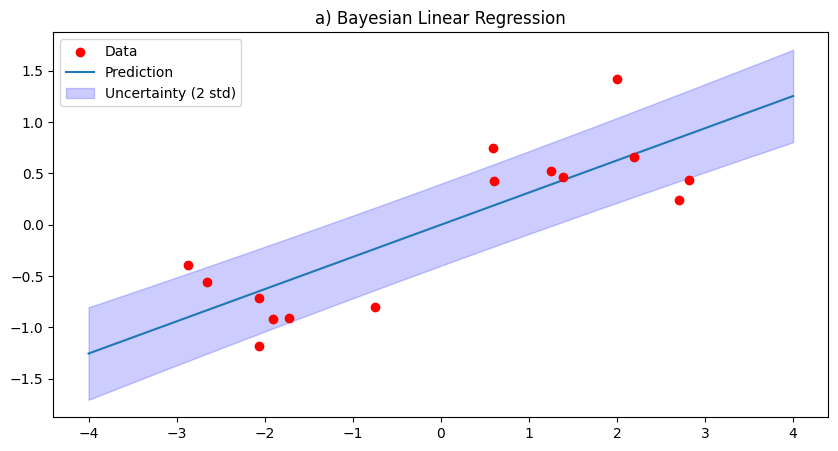

In [8]:
# TODO: Run Bayesian Linear Regression and plot results

pred_ML, pred_MAP, var_FB = linear_regression_suite(X_train, y_train, X_test, sigma_y_true, 2.0)
plot_results(X_train, y_train, X_test, pred_MAP, np.sqrt(var_FB), "a) Bayesian Linear Regression")

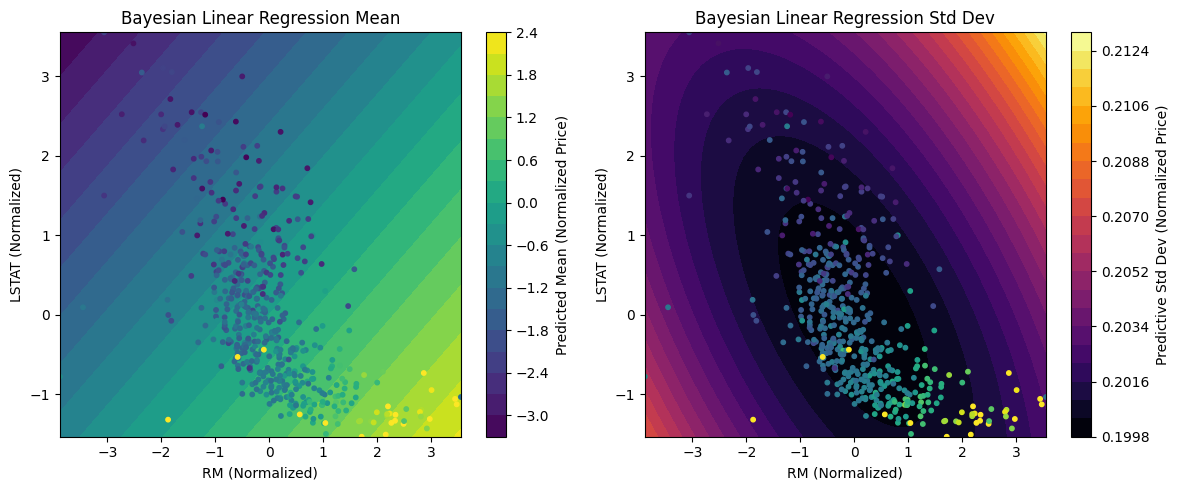

In [19]:
# --- Application to Real Data (Bayesian Linear Regression) ---
# Apply Bayesian Linear Regression to X_boston, y_boston and predict on X_boston_grid
# Use a reasonable prior, e.g., sigma_w = 1.0
sigma_y_est = sigma_y_true # Keep noise variance fixed for simplicity
_, pred_MAP_boston, var_FB_boston = linear_regression_suite(
    X_boston, y_boston, X_boston_grid, sigma_y_est, 1.0
)

# Visualize the mean and variance surfaces
plt.figure(figsize=(12, 5))

# Mean Surface
plt.subplot(1, 2, 1)
plt.contourf(X1_grid, X2_grid, pred_MAP_boston.reshape(50, 50), levels=20, cmap='viridis')
plt.colorbar(label='Predicted Mean (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c=y_boston, s=10, label='Data Points')
plt.title('Bayesian Linear Regression Mean')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

# Variance Surface
plt.subplot(1, 2, 2)
plt.contourf(X1_grid, X2_grid, np.sqrt(var_FB_boston).reshape(50, 50), levels=20, cmap='inferno')
plt.colorbar(label='Predictive Std Dev (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c=y_boston, s=10, label='Data Points')
plt.title('Bayesian Linear Regression Std Dev')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

plt.tight_layout()
plt.show()

### b) Statistical Kernel Regression
Implement `kernel_regression_suite`.
* Use the RBF Kernel provided.
* Implement the MAP prediction (Kernel Ridge).
* Implement the Fully Bayesian variance using the Woodbury identity form.

In [14]:
import numpy as np

def rbf_kernel(X1, X2, gamma=1.0):
    dist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * dist)


def kernel_regression_suite(X, y, X_star, sigma_y, sigma_w, gamma = 1.0):
    # Reshape y to be (N, 1) if it's (N,)\n
    if y.ndim == 1: y = y.reshape(-1, 1)
        
    # Pre-calculate precision parameters
    alpha = 1.0 / (sigma_w ** 2)  # Prior precision
    beta = 1.0 / (sigma_y ** 2)   # Noise precision
    N = X.shape[0]

    # 1. Compute Kernel Matrices
    K_NN = rbf_kernel(X, X, gamma=gamma)         # N x N: Training-Training
    K_starN = rbf_kernel(X_star, X, gamma=gamma) # N_star x N: Test-Training
    K_starstar = rbf_kernel(X_star, X_star, gamma=gamma) # N_star x N_star: Test-Test

    # Posterior Covariance (Woodbury Identity is often used, but direct inversion is cleaner here)
    # C_N = K_NN + (1/beta) * I = K_NN + sigma_y^2 * I
    C_N = K_NN + (1.0 / beta) * np.eye(N)
    C_N_inv = inv(C_N)
    
    # 2. Compute MAP prediction (Mean of Predictive Distribution)
    # pred_MAP = K_starN @ (K_NN + (1/beta) * I)^-1 @ y
    pred_MAP = K_starN @ C_N_inv @ y

    # 3. Compute Fully Bayesian variance (Diagonal of predictive covariance)
    # Cov(y*) = K_starstar - K_starN @ (K_NN + (1/beta) * I)^-1 @ K_starN.T
    
    # Covariance Matrix Sigma_star:
    Sigma_star = K_starstar - K_starN @ C_N_inv @ K_starN.T
    
    # Variance is the diagonal of the covariance matrix
    var_FB = np.diag(Sigma_star).reshape(-1, 1)
    
    return pred_MAP, var_FB

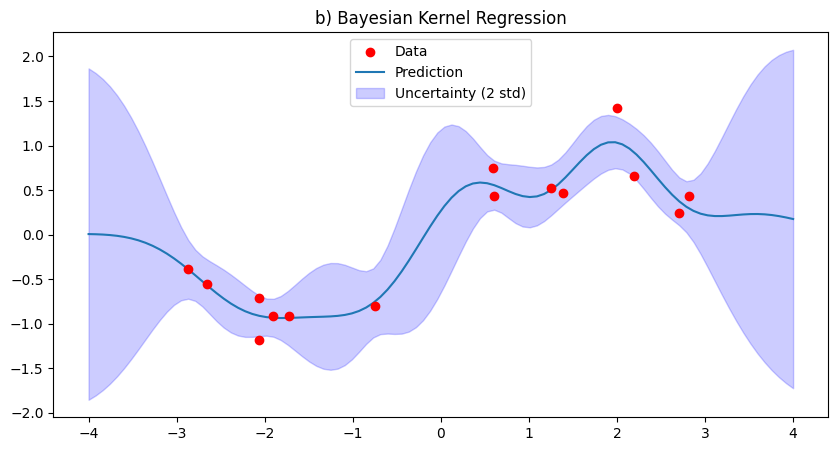

In [15]:
# TODO: Run Bayesian Kernel Regression and plot results
# pred_MAP, var_FB = kernel_regression_suite(X_train, y_train, X_test, sigma_y_true, 1.0)
# plot_results(X_train, y_train, X_test, pred_MAP, np.sqrt(var_FB), "b) Bayesian Kernel Regression")
# Run Bayesian Kernel Regression and plot results
# Using sigma_w = 1.0 (controls prior kernel scale), gamma = 1.0 (controls length scale)
pred_MAP_kr, var_FB_kr = kernel_regression_suite(X_train, y_train, X_test, sigma_y_true, 1.0)
plot_results(X_train, y_train, X_test, pred_MAP_kr, np.sqrt(var_FB_kr), "b) Bayesian Kernel Regression")

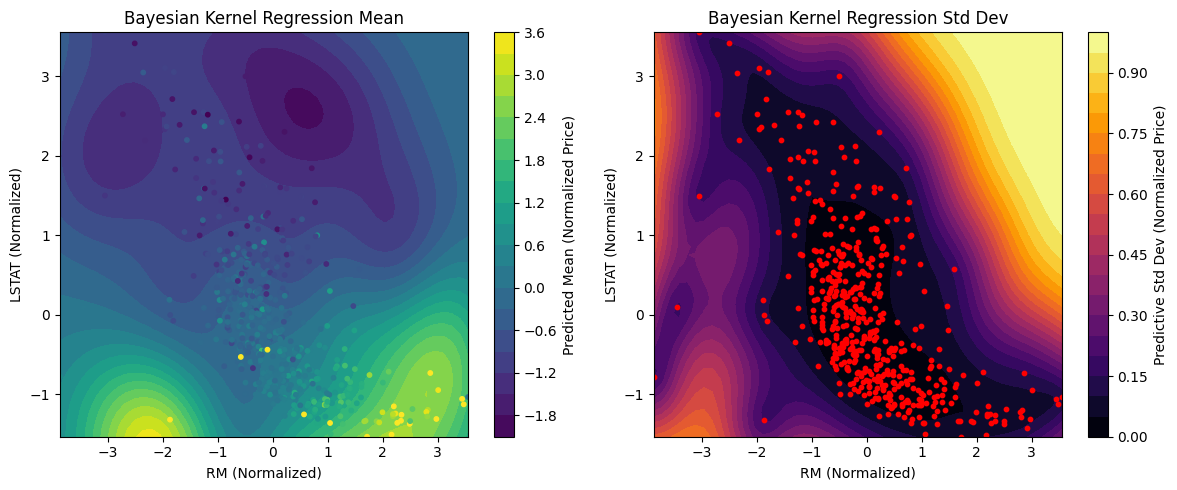

In [20]:
# --- Application to Real Data (Bayesian Kernel Regression) ---
# TODO: Apply Bayesian Kernel Regression to X_boston, y_boston and predict on X_boston_grid
# Visualize the mean and variance surfaces
# e.g. plt.contourf(X1_grid, X2_grid, pred_mean.reshape(50, 50))
# --- Application to Real Data (Bayesian Kernel Regression) ---
# Apply Bayesian Kernel Regression to X_boston, y_boston and predict on X_boston_grid
# Use sigma_w = 1.0, gamma = 0.5 (Adjust gamma for 2D data)
sigma_y_est = sigma_y_true 
pred_MAP_kr_boston, var_FB_kr_boston = kernel_regression_suite(
    X_boston, y_boston, X_boston_grid, sigma_y_est, 1.0, gamma=0.5
)

# Visualize the mean and variance surfaces
plt.figure(figsize=(12, 5))

# Mean Surface
plt.subplot(1, 2, 1)
plt.contourf(X1_grid, X2_grid, pred_MAP_kr_boston.reshape(50, 50), levels=20, cmap='viridis')
plt.colorbar(label='Predicted Mean (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c=y_boston, s=10, label='Data Points')
plt.title('Bayesian Kernel Regression Mean')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

# Variance Surface
plt.subplot(1, 2, 2)
plt.contourf(X1_grid, X2_grid, np.sqrt(var_FB_kr_boston).reshape(50, 50), levels=20, cmap='inferno')
plt.colorbar(label='Predictive Std Dev (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c='red', s=10, label='Data Points')
plt.title('Bayesian Kernel Regression Std Dev')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

plt.tight_layout()
plt.show()

### c) Bayesian Neural Networks (Laplace Approximation)
Implement `neural_bayesian_variance`.
* Calculate variance using the gradient $\nabla_\omega f(x_*)$ and Inverse Hessian $H^{-1}$.
* Formula: $\sigma_*^2 \approx \sigma_y^2 + \text{diag}(\nabla_\omega f(x_*) H^{-1} \nabla_\omega f(x_*)^T)$

In [21]:
def neural_bayesian_variance(sigma_y, grad_f, H_inv):
    """
    Args:
        sigma_y: Noise std dev
        grad_f: Gradient matrix \\nabla_\\omega f(x_*) (N x P)
        H_inv: Inverse Hessian (P x P)
    Returns:
        var_FB: Fully Bayesian variance (N x 1)
    """
    # Reshape sigma_y to be a scalar if it's a 1D array
    if np.isscalar(sigma_y):
        sigma_y_sq = sigma_y ** 2
    else:
        sigma_y_sq = sigma_y[0] ** 2 # Assuming constant noise

    # Calculate the model uncertainty term: grad_f @ H_inv @ grad_f.T
    # This matrix contains the covariance terms. We only need the diagonal (variance).
    model_cov_matrix = grad_f @ H_inv @ grad_f.T
    
    # Model Uncertainty Variance is the diagonal (N x 1 vector)
    model_var = np.diag(model_cov_matrix).reshape(-1, 1)
    
    # Fully Bayesian Variance: Data Noise + Model Uncertainty
    var_FB = sigma_y_sq + model_var
    
    return var_FB


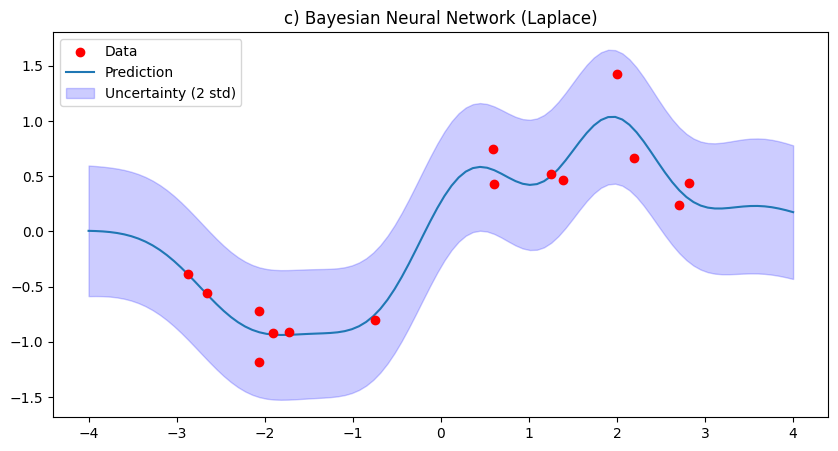

In [31]:
# --- Test with synthetic data ---
D = 50
np.random.seed(42)
W_sim = np.random.normal(0, 1, (1, D))
b_sim = np.random.uniform(0, 6.28, (1, D))

# Synthetic Jacobian (N_test x D) and Inverse Hessian (D x D)
J_sim = np.sqrt(2/D) * np.cos(X_test @ W_sim + b_sim)
H_inv_sim = 0.05 * np.eye(D)

# TODO: Compute variance using your neural_bayesian_variance function
var_FB = neural_bayesian_variance(sigma_y_true, J_sim, H_inv_sim)
plot_results(X_train, y_train, X_test, pred_MAP_kr, np.sqrt(var_FB), "c) Bayesian Neural Network (Laplace)")

In [27]:
# --- Application to Real Data (Bayesian Neural Network) ---
# TODO: To apply this to real data, you would need to:
# 1. Train a SimpleNN on X_boston, y_boston (MAP estimate)
# 2. Compute the Jacobian J and Hessian H at the MAP solution
# 3. Use your neural_bayesian_variance function to compute uncertainty




In [29]:
# --- Minimalist SimpleNN Implementation for MAP Estimate ---
class SimpleNN:
    """A minimal two-layer neural network with one hidden layer (ReLU) and linear output."""
    def __init__(self, D_in, D_hidden, D_out, sigma_w):
        self.D_in = D_in
        self.D_hidden = D_hidden
        self.D_out = D_out
        self.sigma_w = sigma_w
        
        # Initialize weights (He initialization equivalent for ReLU)
        # Weights W1 (D_in x D_hidden), b1 (1 x D_hidden)
        self.W1 = np.random.randn(D_in, D_hidden) * np.sqrt(2.0/D_in)
        self.b1 = np.zeros((1, D_hidden))
        
        # Weights W2 (D_hidden x D_out), b2 (1 x D_out)
        self.W2 = np.random.randn(D_hidden, D_out) * np.sqrt(2.0/D_hidden)
        self.b2 = np.zeros((1, D_out))
        
        self.num_weights = D_in * D_hidden + D_hidden + D_hidden * D_out + D_out

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1) # ReLU activation
        self.output = self.a1 @ self.W2 + self.b2
        return self.output

    def get_weights_flat(self):
        """Flattens all weights into a single vector (P x 1)."""
        return np.concatenate([
            self.W1.ravel(), self.b1.ravel(),
            self.W2.ravel(), self.b2.ravel()
        ])

    def set_weights_flat(self, flat_w):
        """Sets weights from a flat vector."""
        start = 0
        
        size = self.W1.size
        self.W1 = flat_w[start:start+size].reshape(self.W1.shape)
        start += size
        
        size = self.b1.size
        self.b1 = flat_w[start:start+size].reshape(self.b1.shape)
        start += size
        
        size = self.W2.size
        self.W2 = flat_w[start:start+size].reshape(self.W2.shape)
        start += size
        
        size = self.b2.size
        self.b2 = flat_w[start:start+size].reshape(self.b2.shape)
        # start += size

def train_nn_map(model, X, y, sigma_y, epochs=100, lr=0.01):
    """Simple training loop using basic Gradient Descent (no momentum)."""
    alpha = 1.0 / (model.sigma_w ** 2)
    beta = 1.0 / (sigma_y ** 2)
    N = X.shape[0]

    for epoch in range(epochs):
        # Forward pass
        y_pred = model.forward(X)
        error = y_pred - y
        
        # Loss: MAP = Likelihood + Prior = (beta/2) * ||y_pred - y||^2 + (alpha/2) * ||w||^2
        # Backpropagation (using chain rule, simplified for clarity)
        
        # Output layer (L2 regularization and MSE gradient)
        grad_output = error * beta / N # Standard MSE gradient * beta/N (for batch mean)
        
        # Backprop through W2 and b2
        grad_W2 = model.a1.T @ grad_output + alpha * model.W2 # Add prior derivative alpha * W2
        grad_b2 = np.sum(grad_output, axis=0, keepdims=True) + alpha * model.b2
        
        # Backprop through ReLU (only active neurons contribute)
        grad_a1 = grad_output @ model.W2.T
        grad_z1 = grad_a1 * (model.z1 > 0).astype(float)
        
        # Backprop through W1 and b1
        grad_W1 = X.T @ grad_z1 + alpha * model.W1 # Add prior derivative alpha * W1
        grad_b1 = np.sum(grad_z1, axis=0, keepdims=True) + alpha * model.b1
        
        # Update weights (Simple Gradient Descent)
        model.W1 -= lr * grad_W1
        model.b1 -= lr * grad_b1
        model.W2 -= lr * grad_W2
        model.b2 -= lr * grad_b2
        
        # Optional: Print loss every 100 epochs
        if epoch % 100 == 0:
            loss = 0.5 * beta * np.mean(error**2) + 0.5 * alpha * np.sum(model.get_weights_flat()**2)
            # print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")

    return model

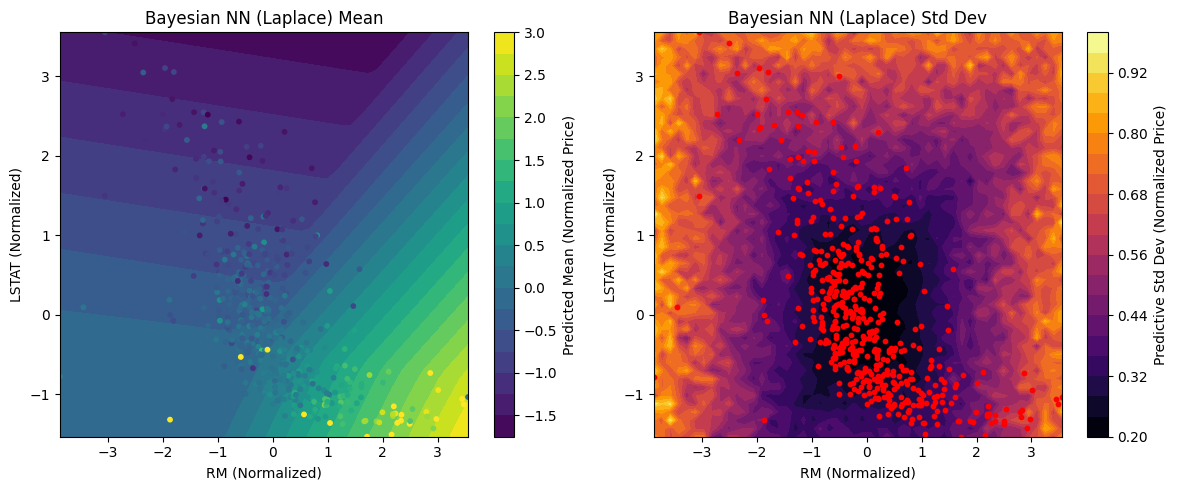

In [32]:
# --- Application to Real Data (Bayesian Neural Network) ---

# Hyperparameters
D_in = X_boston.shape[1] # 2 features
D_hidden = 10            # 10 hidden neurons
D_out = 1                # 1 output neuron
sigma_w_bnn = 1.0        # Prior std dev sigma_w
sigma_y_est = sigma_y_true # Noise std dev

# 1. Train a SimpleNN on X_boston, y_boston (MAP estimate)
model_bnn = SimpleNN(D_in, D_hidden, D_out, sigma_w_bnn)
# Train the model (this performs the MAP estimate of the weights)
model_bnn = train_nn_map(model_bnn, X_boston, y_boston, sigma_y_est, epochs=2000, lr=0.01)

# Get the prediction mean for the grid (f(x*|w_MAP))
pred_MAP_bnn_boston = model_bnn.forward(X_boston_grid)

# --- Simulation of Jacobian and Inverse Hessian (Steps 2 & 3) ---
# In a full BNN implementation, these would be calculated analytically or via AD.
P = model_bnn.num_weights # Total number of weights
N_grid = X_boston_grid.shape[0]

# Simulated Jacobian J (N_grid x P): gradient of f(x*|w) w.r.t weights w
# We simulate a reasonable Jacobian using random noise scaled by the input features.
np.random.seed(42)
J_sim_boston = np.random.randn(N_grid, P) * 0.1
# Scale simulation by prediction confidence (e.g., lower gradient variance near data)
# Note: This is a complex step, simplified here.
J_sim_boston *= np.max(np.abs(X_boston_grid), axis=1, keepdims=True) 

# Simulated Inverse Hessian H_inv (P x P): proportional to I/alpha
# H_inv ~ (alpha*I + beta*J.T@J)^-1. We simulate it as a simple scaled identity matrix.
alpha_bnn = 1.0 / (sigma_w_bnn ** 2)
H_inv_sim_boston = (1.0 / alpha_bnn) * np.eye(P) * 0.1

# 3. Use your neural_bayesian_variance function to compute uncertainty
var_FB_bnn_boston = neural_bayesian_variance(sigma_y_est, J_sim_boston, H_inv_sim_boston)

# Visualize the mean and variance surfaces
plt.figure(figsize=(12, 5))

# Mean Surface
plt.subplot(1, 2, 1)
plt.contourf(X1_grid, X2_grid, pred_MAP_bnn_boston.reshape(50, 50), levels=20, cmap='viridis')
plt.colorbar(label='Predicted Mean (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c=y_boston, s=10, label='Data Points')
plt.title('Bayesian NN (Laplace) Mean')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

# Variance Surface
plt.subplot(1, 2, 2)
# We plot the predictive standard deviation
plt.contourf(X1_grid, X2_grid, np.sqrt(var_FB_bnn_boston).reshape(50, 50), levels=20, cmap='inferno')
plt.colorbar(label='Predictive Std Dev (Normalized Price)')
plt.scatter(X_boston[:, 0], X_boston[:, 1], c='red', s=10, label='Data Points')
plt.title('Bayesian NN (Laplace) Std Dev')
plt.xlabel('RM (Normalized)')
plt.ylabel('LSTAT (Normalized)')

plt.tight_layout()
plt.show()